In [1]:
# Install dependencies (run once)
!pip install pandas numpy matplotlib seaborn -q


## 1. Load & clean data
Collapses 5 implicates per household into one row, creates derived variables.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("SCFP2022.csv")
print(f"Raw file: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Key variables
key_vars = [
    'YY1','Y1','WGT','AGE','AGECL','EDCL','RACECL4','LF',
    'INCOME','WAGEINC','IRAKH','THRIFT','RETQLIQ','HRETQLIQ',
    'ANYPEN','DCPLANCJ','EDN_INST','HEDN_INST',
    'DEBT','NETWORTH','ASSET','FIN','CCBAL','NWCAT','INCCAT'
]

analysis = df[key_vars].copy()
continuous = ['WGT','INCOME','WAGEINC','IRAKH','THRIFT','RETQLIQ',
              'EDN_INST','DEBT','NETWORTH','ASSET','FIN','CCBAL','DCPLANCJ']
categorical = [c for c in key_vars if c not in continuous + ['YY1','Y1']]

avg_cont = analysis.groupby('YY1')[continuous].mean()
cat_vals  = analysis.groupby('YY1')[categorical].first()
clean = pd.concat([avg_cont, cat_vals], axis=1).reset_index()

# Derived variables
clean['has_student_debt'] = (clean['EDN_INST'] > 0).astype(int)
clean['has_ira']          = (clean['IRAKH'] > 0).astype(int)
clean['has_retirement']   = clean['HRETQLIQ'].astype(int)

age_labels  = {1:'18-34',2:'35-44',3:'45-54',4:'55-64',5:'65-74',6:'75+'}
inc_labels  = {1:'Bottom 20%',2:'20-39.9%',3:'40-59.9%',4:'60-79.9%',5:'80-89.9%',6:'Top 10%'}

clean['age_group']    = clean['AGECL'].map(age_labels)
clean['income_group'] = clean['INCCAT'].map(inc_labels)

print(f"Cleaned: {len(clean):,} households")
print(f"  Has student debt: {clean['has_student_debt'].sum():,} ({clean['has_student_debt'].mean()*100:.1f}%)")
print(f"  Has IRA:          {clean['has_ira'].sum():,} ({clean['has_ira'].mean()*100:.1f}%)")
clean.head(3)


Raw file: 22,975 rows x 357 columns
Cleaned: 4,595 households
  Has student debt: 812 (17.7%)
  Has IRA:          1,790 (39.0%)


,YY1,WGT,INCOME,WAGEINC,IRAKH,THRIFT,RETQLIQ,EDN_INST,DEBT,NETWORTH,...,HRETQLIQ,ANYPEN,HEDN_INST,NWCAT,INCCAT,has_student_debt,has_ira,has_retirement,age_group,income_group
0,1,3129.669426,36448.346693,0.000000,132200.0,0.0,132200.0,0.0,291800.0,635360.0,...,1,0,0,4,2,0,1,1,65-74,20-39.9%
1,2,248.461212,224829.659320,9857.915832,100000.0,0.0,100000.0,0.0,519100.0,722780.0,...,1,0,0,4,5,0,1,1,45-54,80-89.9%
2,3,666.788307,464575.901804,0.000000,489200.0,0.0,489200.0,0.0,18426000.0,43515270.0,...,1,1,0,5,6,0,1,1,65-74,Top 10%


## 2. Weighted statistics helpers

In [3]:
def wavg(vals, wts):
    mask = (~np.isnan(vals)) & (~np.isnan(wts))
    return np.average(vals[mask], weights=wts[mask])

def wmedian(vals, wts, q=0.5):
    d = pd.DataFrame({'v': vals, 'w': wts}).dropna().sort_values('v')
    cumw = d['w'].cumsum()
    return float(d.loc[cumw >= d['w'].sum() * q, 'v'].iloc[0])

# Pre-compute all chart data
age_order = ['18-34','35-44','45-54','55-64','65-74']
inc_order = ['Bottom 20%','20-39.9%','40-59.9%','60-79.9%','80-89.9%','Top 10%']

age_no, age_yes, bal_no, bal_yes = [], [], [], []
for age in age_order:
    for lst, debt in [(age_no,0),(age_yes,1)]:
        s = clean[(clean['age_group']==age) & (clean['has_student_debt']==debt)]
        lst.append(np.average(s['has_ira'], weights=s['WGT']) * 100)
    for lst, debt in [(bal_no,0),(bal_yes,1)]:
        s = clean[(clean['age_group']==age) & (clean['has_student_debt']==debt)]
        lst.append(wavg(s['IRAKH'].values, s['WGT'].values))

inc_no, inc_yes, incbal_no, incbal_yes = [], [], [], []
for inc in inc_order:
    for lst, debt in [(inc_no,0),(inc_yes,1)]:
        s = clean[(clean['income_group']==inc) & (clean['has_student_debt']==debt)]
        if len(s) >= 5:
            lst.append(np.average(s['has_ira'], weights=s['WGT']) * 100)
        else:
            lst.append(np.nan)
    for lst, debt in [(incbal_no,0),(incbal_yes,1)]:
        s = clean[(clean['income_group']==inc) & (clean['has_student_debt']==debt)]
        if len(s) >= 5:
            lst.append(wavg(s['IRAKH'].values, s['WGT'].values))
        else:
            lst.append(np.nan)

print("Chart data computed.")


Chart data computed.


## 3. Summary metrics

In [4]:
for debt, label in [(0,'No student debt'),(1,'Has student debt')]:
    s = clean[clean['has_student_debt'] == debt]
    w = s['WGT']
    print(f"\n{label} (n={len(s):,})")
    print(f"  % with IRA:              {np.average(s['has_ira'], weights=w)*100:.1f}%")
    print(f"  Mean IRA balance:        ${wavg(s['IRAKH'].values, w.values):,.0f}")
    print(f"  Mean retirement (total): ${wavg(s['RETQLIQ'].values, w.values):,.0f}")



No student debt (n=3,783)
  % with IRA:              32.2%
  Mean IRA balance:        $115,869
  Mean retirement (total): $212,478

Has student debt (n=812)
  % with IRA:              27.1%
  Mean IRA balance:        $23,719
  Mean retirement (total): $72,840


## 4. Charts
### Chart settings

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Colour palette
C_TEAL   = '#0F6E56'
C_PURPLE = '#534AB7'
C_TEAL_L = '#9FE1CB'
C_PUR_L  = '#AFA9EC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  True,
    'axes.spines.bottom':True,
    'axes.grid':         True,
    'axes.grid.axis':    'y',
    'grid.color':        '#e8e8e8',
    'grid.linewidth':    0.6,
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'xtick.bottom':      True,
    'ytick.left':        True,
})

def fmt_dollar(x, pos):
    if x >= 1_000_000: return f'${x/1_000_000:.1f}M'
    if x >= 1_000:     return f'${x/1_000:.0f}k'
    return f'${x:.0f}'

print("Style configured.")


Style configured.


### Chart 1 — IRA ownership rate by age group

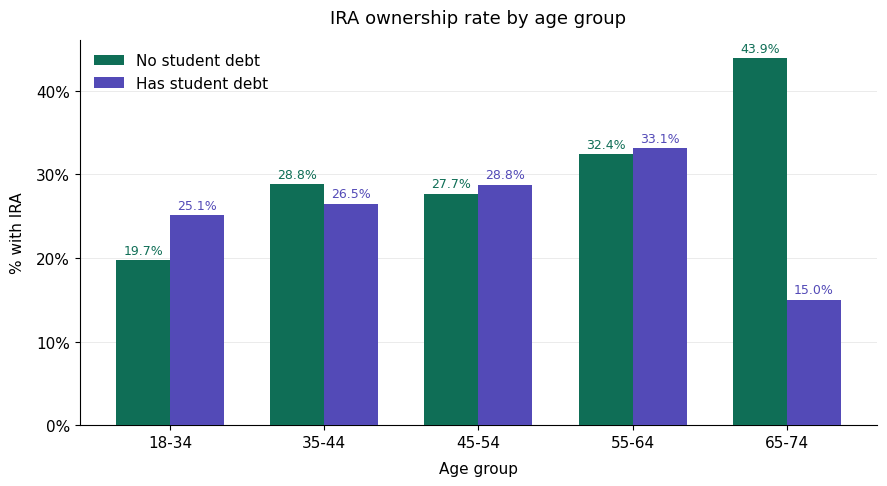

Saved: chart1_ira_by_age.png


In [7]:
x = np.arange(len(age_order))
w_bar = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x - w_bar/2, age_no,  w_bar, label='No student debt', color=C_TEAL,   zorder=3)
b2 = ax.bar(x + w_bar/2, age_yes, w_bar, label='Has student debt', color=C_PURPLE, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(age_order)
ax.set_xlabel('Age group', labelpad=8)
ax.set_ylabel('% with IRA', labelpad=8)
ax.set_title('IRA ownership rate by age group', fontsize=13, fontweight='normal', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax.legend(frameon=False)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9,
            color=bar.get_facecolor())

plt.tight_layout()
plt.savefig('chart1_ira_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_ira_by_age.png")


### Chart 2 — IRA ownership rate by income group

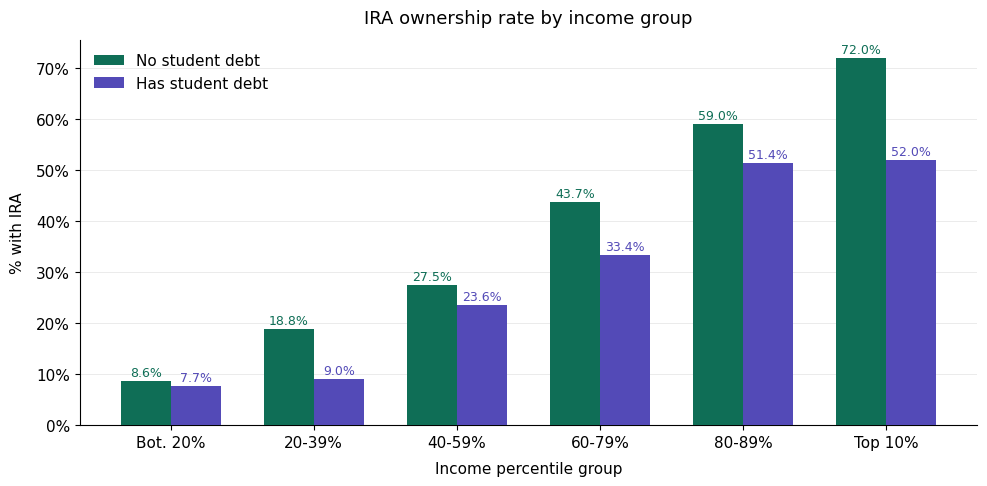

Saved: chart2_ira_by_income.png


In [8]:
inc_labels_short = ['Bot. 20%','20-39%','40-59%','60-79%','80-89%','Top 10%']
x2 = np.arange(len(inc_order))

fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(x2 - w_bar/2, inc_no,  w_bar, label='No student debt', color=C_TEAL,   zorder=3)
b2 = ax.bar(x2 + w_bar/2, inc_yes, w_bar, label='Has student debt', color=C_PURPLE, zorder=3)

ax.set_xticks(x2)
ax.set_xticklabels(inc_labels_short)
ax.set_xlabel('Income percentile group', labelpad=8)
ax.set_ylabel('% with IRA', labelpad=8)
ax.set_title('IRA ownership rate by income group', fontsize=13, fontweight='normal', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax.legend(frameon=False)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9,
                color=bar.get_facecolor())

plt.tight_layout()
plt.savefig('chart2_ira_by_income.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart2_ira_by_income.png")


### Chart 3 — Mean IRA balance by age group

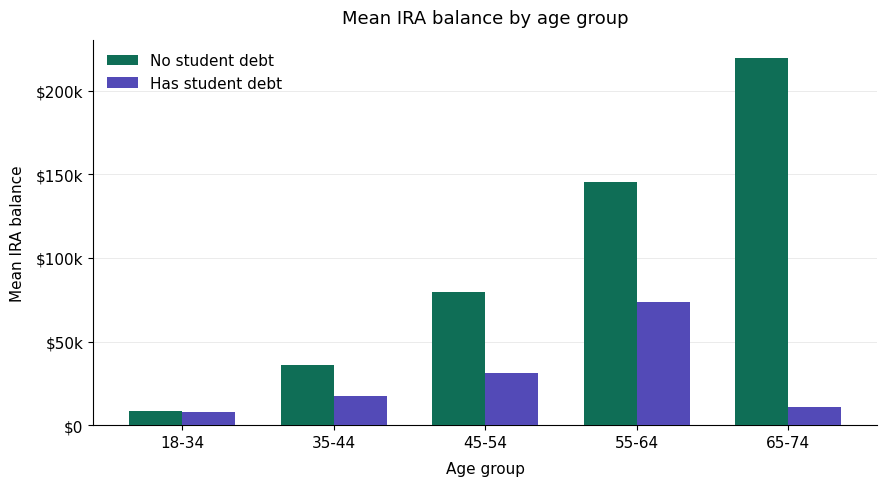

Saved: chart3_balance_by_age.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x - w_bar/2, bal_no,  w_bar, label='No student debt', color=C_TEAL,   zorder=3)
b2 = ax.bar(x + w_bar/2, bal_yes, w_bar, label='Has student debt', color=C_PURPLE, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(age_order)
ax.set_xlabel('Age group', labelpad=8)
ax.set_ylabel('Mean IRA balance', labelpad=8)
ax.set_title('Mean IRA balance by age group', fontsize=13, fontweight='normal', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('chart3_balance_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart3_balance_by_age.png")


### Chart 4 — Mean IRA balance by income group

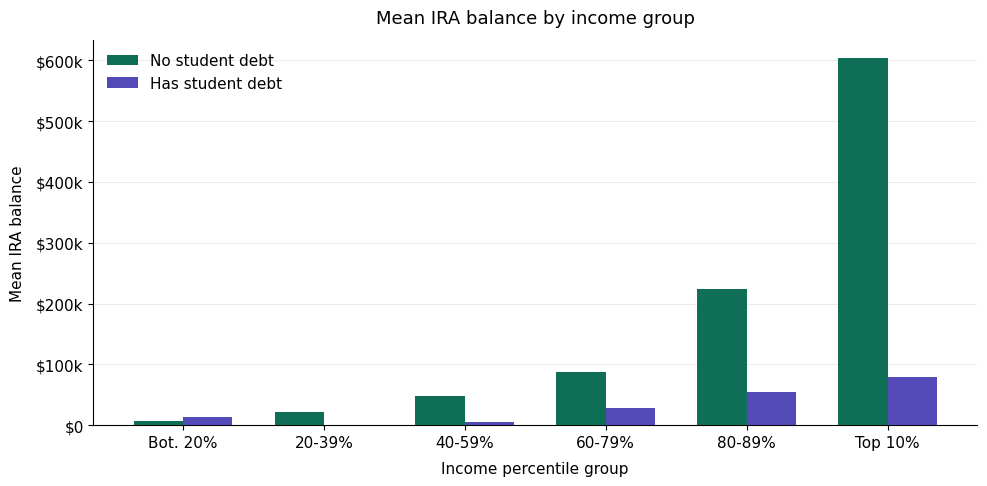

Saved: chart4_balance_by_income.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(x2 - w_bar/2, incbal_no,  w_bar, label='No student debt', color=C_TEAL,   zorder=3)
b2 = ax.bar(x2 + w_bar/2, incbal_yes, w_bar, label='Has student debt', color=C_PURPLE, zorder=3)

ax.set_xticks(x2)
ax.set_xticklabels(inc_labels_short)
ax.set_xlabel('Income percentile group', labelpad=8)
ax.set_ylabel('Mean IRA balance', labelpad=8)
ax.set_title('Mean IRA balance by income group', fontsize=13, fontweight='normal', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('chart4_balance_by_income.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart4_balance_by_income.png")


### Chart 5 — Regression: OLS coefficients (log IRA balance)

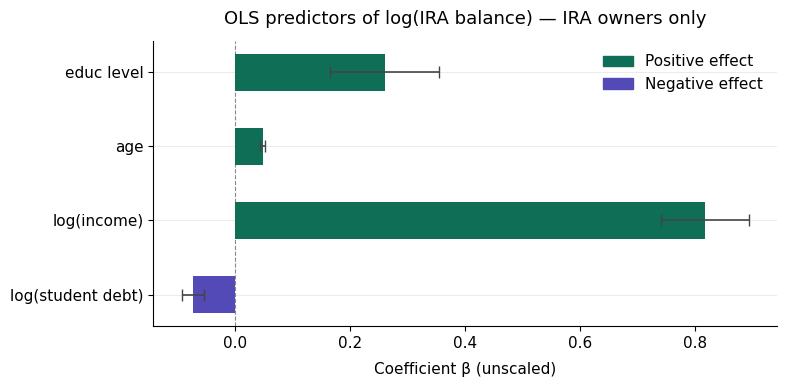

                 Results: Weighted least squares
Model:              WLS              Adj. R-squared:     0.399    
Dependent Variable: log_ira          AIC:                8296.4874
Date:               2026-04-16 04:39 BIC:                8323.8868
No. Observations:   1772             Log-Likelihood:     -4143.2  
Df Model:           4                F-statistic:        295.2    
Df Residuals:       1767             Prob (F-statistic): 1.44e-194
R-squared:          0.401            Scale:              2.3893   
-------------------------------------------------------------------
                Coef.   Std.Err.     t     P>|t|    [0.025   0.975]
-------------------------------------------------------------------
const          -1.9309    0.4766  -4.0511  0.0001  -2.8657  -0.9961
log_edn        -0.0724    0.0101  -7.1724  0.0000  -0.0922  -0.0526
log_income      0.8159    0.0390  20.9130  0.0000   0.7394   0.8925
AGE             0.0483    0.0023  20.5707  0.0000   0.0437   0.0529
EDCL  

In [11]:
import statsmodels.api as sm

reg = clean[clean['IRAKH'] > 0].copy()
reg = reg[reg['INCOME'] > 0].dropna(subset=['IRAKH','EDN_INST','INCOME','AGE','EDCL'])
reg['log_ira']    = np.log(reg['IRAKH'])
reg['log_edn']    = np.log(reg['EDN_INST'] + 1)
reg['log_income'] = np.log(reg['INCOME'])

features = ['log_edn','log_income','AGE','EDCL']
X = sm.add_constant(reg[features])
w_norm = reg['WGT'] / reg['WGT'].mean()
model = sm.WLS(reg['log_ira'], X, weights=w_norm).fit()

feat_labels = ['log(student debt)','log(income)','age','educ level']
coefs = model.params[features].values
cis   = model.conf_int().loc[features].values
colors = [C_PURPLE if c < 0 else C_TEAL for c in coefs]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(feat_labels))

for i, (c, ci, col) in enumerate(zip(coefs, cis, colors)):
    ax.barh(i, c, color=col, height=0.5, zorder=3)
    ax.errorbar(c, i, xerr=[[c - ci[0]], [ci[1] - c]],
                fmt='none', color='#444', capsize=4, linewidth=1.2, zorder=4)

ax.axvline(0, color='#888', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_labels)
ax.set_xlabel('Coefficient β (unscaled)', labelpad=8)
ax.set_title('OLS predictors of log(IRA balance) — IRA owners only', fontsize=13, fontweight='normal', pad=12)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=C_TEAL,label='Positive effect'),
                   Patch(color=C_PURPLE,label='Negative effect')], frameon=False)

plt.tight_layout()
plt.savefig('chart5_ols_coefs.png', dpi=150, bbox_inches='tight')
plt.show()
print(model.summary2())


### Chart 6 — Logistic regression: odds ratios with 95% confidence intervals

                 Results: Generalized linear model
Model:                GLM               AIC:             4485.4877  
Link Function:        Logit             BIC:             -33891.3183
Dependent Variable:   has_ira           Log-Likelihood:  -2237.7    
Date:                 2026-04-16 04:39  LL-Null:         -2826.0    
No. Observations:     4559              Deviance:        4475.5     
Df Model:             4                 Pearson chi2:    4.68e+03   
Df Residuals:         4554              Scale:           1.0000     
Method:               IRLS                                          
--------------------------------------------------------------------
                  Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
--------------------------------------------------------------------
const            -14.0049   0.5463 -25.6375 0.0000 -15.0755 -12.9342
has_student_debt  -0.3379   0.0964  -3.5052 0.0005  -0.5268  -0.1489
log_income         0.9048   0.0468  19.3139 0.0000  

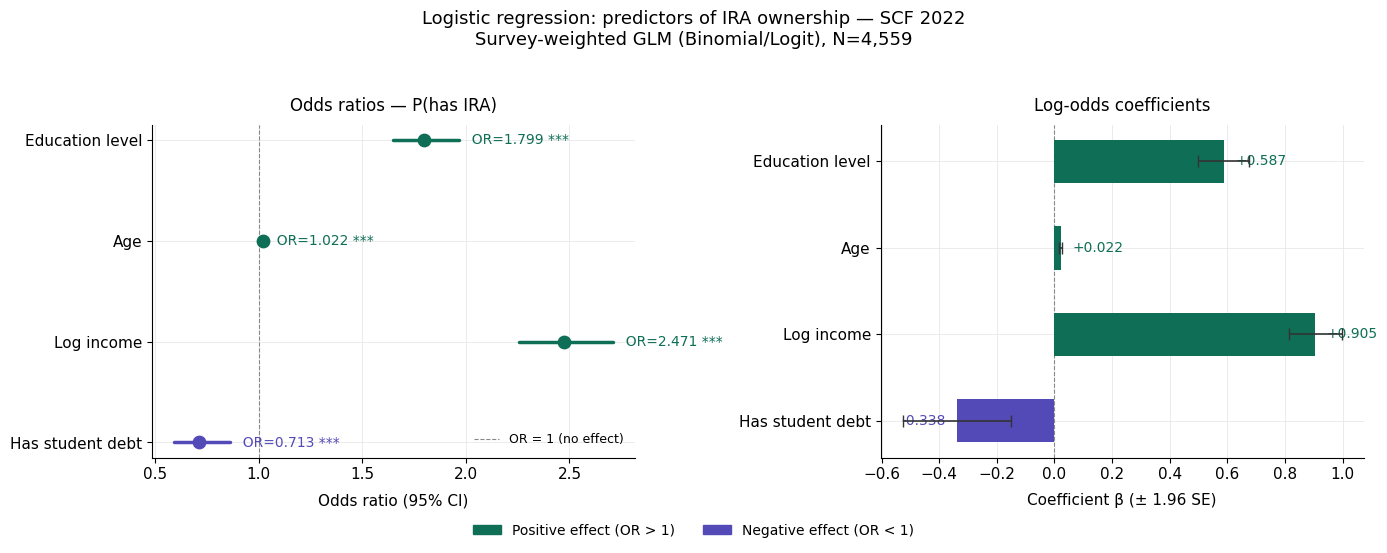

Saved: chart6_logistic_regression.png

── Odds ratio summary ──────────────────────────────────
Variable                     β      SE       OR              95% CI         p  Sig
──────────────────────────────────────────────────────────────────────────────
Has student debt       -0.3379  0.0964   0.7133  [0.5905, 0.8616]    0.0005  ***
Log income             +0.9048  0.0468   2.4715  [2.2546, 2.7091]    0.0000  ***
Age                    +0.0221  0.0024   1.0223  [1.0176, 1.0270]    0.0000  ***
Education level        +0.5873  0.0453   1.7992  [1.6462, 1.9664]    0.0000  ***


In [12]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Fit survey-weighted logistic regression (GLM / Binomial / Logit) ──────
reg_log = clean.dropna(subset=['IRAKH','EDN_INST','INCOME','AGE','EDCL']).copy()
reg_log = reg_log[reg_log['INCOME'] > 0].copy()
reg_log['log_income'] = np.log(reg_log['INCOME'])

features_log = ['has_student_debt', 'log_income', 'AGE', 'EDCL']
X_log = sm.add_constant(reg_log[features_log])
y_log = reg_log['has_ira']
w_norm_log = reg_log['WGT'] / reg_log['WGT'].mean()

glm_model = sm.GLM(
    y_log, X_log,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
    var_weights=w_norm_log
).fit()

print(glm_model.summary2())

# ── Extract coefficients (drop intercept for OR plot) ─────────────────────
feat_names = ['has_student_debt', 'log_income', 'AGE', 'EDCL']
feat_labels = ['Has student debt', 'Log income', 'Age', 'Education level']

params = glm_model.params[feat_names]
conf   = glm_model.conf_int().loc[feat_names]
pvals  = glm_model.pvalues[feat_names]

ORs   = np.exp(params.values)
OR_lo = np.exp(conf[0].values)
OR_hi = np.exp(conf[1].values)

colors = [C_PURPLE if or_ < 1 else C_TEAL for or_ in ORs]

# ── Chart 6a: Odds ratio dot plot ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
y_pos = np.arange(len(feat_labels))

for i, (or_, lo, hi, col, p) in enumerate(zip(ORs, OR_lo, OR_hi, colors, pvals.values)):
    ax.plot([lo, hi], [i, i], color=col, linewidth=2.5, solid_capstyle='round', zorder=3)
    ax.scatter(or_, i, color=col, s=80, zorder=4)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    ax.text(hi + 0.02, i, f'  OR={or_:.3f} {sig}', va='center', fontsize=10, color=col)

ax.axvline(1.0, color='#888', linewidth=0.8, linestyle='--', label='OR = 1 (no effect)')
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_labels)
ax.set_xlabel('Odds ratio (95% CI)', labelpad=8)
ax.set_title('Odds ratios — P(has IRA)', fontsize=12, fontweight='normal', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', color='#e8e8e8', linewidth=0.6)
ax.legend(frameon=False, fontsize=9)

# ── Chart 6b: Coefficient bar chart with CIs ──────────────────────────────
ax = axes[1]
bse  = glm_model.bse[feat_names].values
betas = params.values

bars = ax.barh(y_pos, betas, height=0.5,
               color=colors, zorder=3)
for i, (b, se, col) in enumerate(zip(betas, bse, colors)):
    ax.errorbar(b, i, xerr=1.96*se,
                fmt='none', color='#333', capsize=4, linewidth=1.2, zorder=4)
    ax.text(b + (0.04 if b >= 0 else -0.04), i,
            f'{b:+.3f}', va='center',
            ha='left' if b >= 0 else 'right',
            fontsize=10, color=col)

ax.axvline(0, color='#888', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_labels)
ax.set_xlabel('Coefficient β (± 1.96 SE)', labelpad=8)
ax.set_title('Log-odds coefficients', fontsize=12, fontweight='normal', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', color='#e8e8e8', linewidth=0.6)

# Shared legend
pos_patch = mpatches.Patch(color=C_TEAL,   label='Positive effect (OR > 1)')
neg_patch = mpatches.Patch(color=C_PURPLE, label='Negative effect (OR < 1)')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
           ncol=2, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.05))

fig.suptitle(
    'Logistic regression: predictors of IRA ownership — SCF 2022\n'
    'Survey-weighted GLM (Binomial/Logit), N=4,559',
    fontsize=13, fontweight='normal', y=1.03
)

plt.tight_layout()
plt.savefig('chart6_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart6_logistic_regression.png")

# ── Print odds ratio table ─────────────────────────────────────────────────
print("\n── Odds ratio summary ──────────────────────────────────")
print(f"{'Variable':<22} {'β':>7}  {'SE':>6}  {'OR':>7}  {'95% CI':>18}  {'p':>8}  Sig")
print("─" * 78)
for name, label, b, se, or_, lo, hi, p in zip(
        feat_names, feat_labels,
        betas, bse, ORs, OR_lo, OR_hi, pvals.values):
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{label:<22} {b:+7.4f}  {se:6.4f}  {or_:7.4f}  [{lo:.4f}, {hi:.4f}]  {p:8.4f}  {sig}")


### All charts combined — single figure

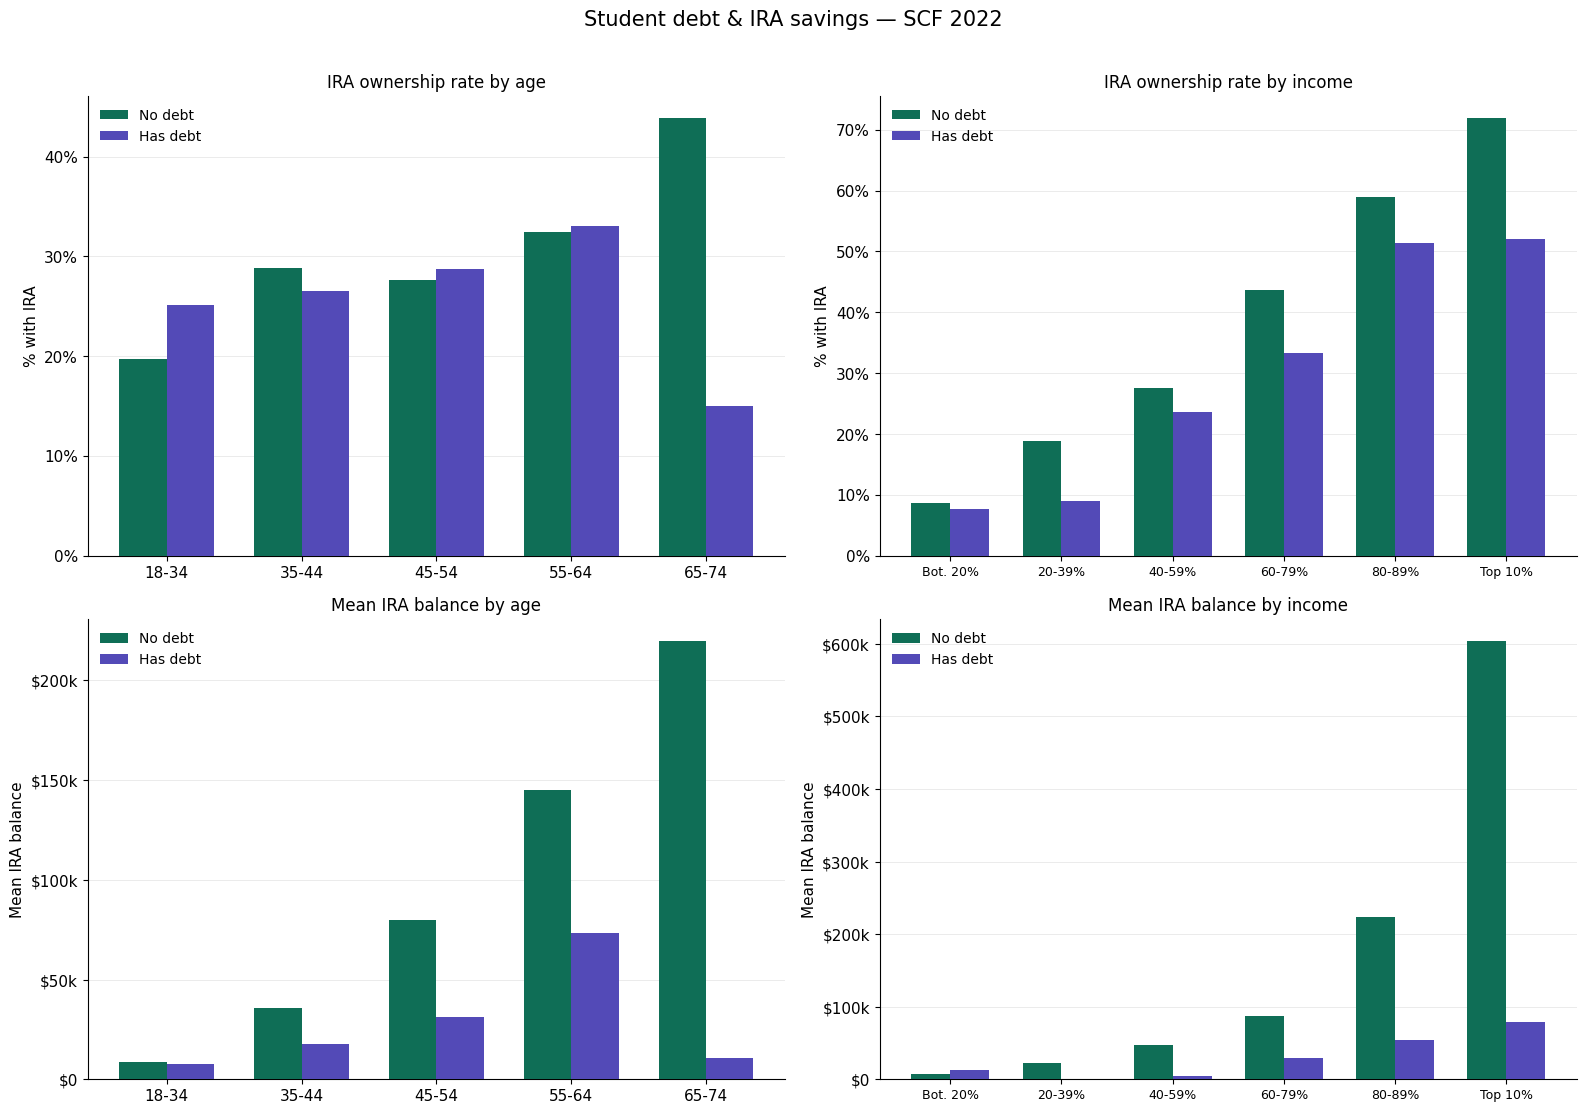

Saved: scf2022_all_charts.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Student debt & IRA savings — SCF 2022', fontsize=15, fontweight='normal', y=1.01)

# Chart 1
ax = axes[0, 0]
b1 = ax.bar(x - w_bar/2, age_no,  w_bar, label='No debt', color=C_TEAL,   zorder=3)
b2 = ax.bar(x + w_bar/2, age_yes, w_bar, label='Has debt', color=C_PURPLE, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(age_order)
ax.set_title('IRA ownership rate by age', fontsize=12, fontweight='normal')
ax.set_ylabel('% with IRA')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax.legend(frameon=False, fontsize=10)

# Chart 2
ax = axes[0, 1]
b1 = ax.bar(x2 - w_bar/2, inc_no,  w_bar, label='No debt', color=C_TEAL,   zorder=3)
b2 = ax.bar(x2 + w_bar/2, inc_yes, w_bar, label='Has debt', color=C_PURPLE, zorder=3)
ax.set_xticks(x2); ax.set_xticklabels(inc_labels_short, fontsize=9)
ax.set_title('IRA ownership rate by income', fontsize=12, fontweight='normal')
ax.set_ylabel('% with IRA')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax.legend(frameon=False, fontsize=10)

# Chart 3
ax = axes[1, 0]
ax.bar(x - w_bar/2, bal_no,  w_bar, label='No debt', color=C_TEAL,   zorder=3)
ax.bar(x + w_bar/2, bal_yes, w_bar, label='Has debt', color=C_PURPLE, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(age_order)
ax.set_title('Mean IRA balance by age', fontsize=12, fontweight='normal')
ax.set_ylabel('Mean IRA balance')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.legend(frameon=False, fontsize=10)

# Chart 4
ax = axes[1, 1]
ax.bar(x2 - w_bar/2, incbal_no,  w_bar, label='No debt', color=C_TEAL,   zorder=3)
ax.bar(x2 + w_bar/2, incbal_yes, w_bar, label='Has debt', color=C_PURPLE, zorder=3)
ax.set_xticks(x2); ax.set_xticklabels(inc_labels_short, fontsize=9)
ax.set_title('Mean IRA balance by income', fontsize=12, fontweight='normal')
ax.set_ylabel('Mean IRA balance')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.legend(frameon=False, fontsize=10)

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#e8e8e8', linewidth=0.6)

plt.tight_layout()
plt.savefig('scf2022_all_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scf2022_all_charts.png")
